In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import regionmask
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cmocean

from unseen import fileio

import utils

## Plot grid

In [2]:
infile = '/g/data/xv83/unseen-projects/outputs/bias/data/rx1day_AGCD-CSIRO_1901-2024_annual-jul-to-jun_AUS300i.nc'
ds = fileio.open_dataset(infile)
overlap_threshold = 0.67
shape_gpd = gpd.read_file('/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp')
shape_rgm = regionmask.from_geopandas(
    shape_gpd,
    names="AUS_NAME21",
    abbrevs="AUS_CODE21",
    name="australia"
)
frac = shape_rgm.mask_3D_frac_approx(ds)
mask = frac.sel(region=0) >= overlap_threshold

In [3]:
def highlight_grid_box(ax, target_lat_index, target_lon_index, color='tab:red'):
    """Draw a red box around a grid point."""
    
    target_lat = float(mask.lat[target_lat_index])
    target_lon = float(mask.lon[target_lon_index])
    ax.plot(
        [target_lon - 1.5, target_lon + 1.5],
        [target_lat - 1.5, target_lat - 1.5],
        transform=ccrs.PlateCarree(),
        color=color,
        lw=2.5
    )
    ax.plot(
        [target_lon - 1.5, target_lon + 1.5],
        [target_lat + 1.5, target_lat + 1.5],
        transform=ccrs.PlateCarree(),
        color=color,
        lw=2.5
    )
    ax.plot(
        [target_lon - 1.5, target_lon - 1.5],
        [target_lat - 1.5, target_lat + 1.5],
        transform=ccrs.PlateCarree(),
        color=color,
        lw=2.5
    )
    ax.plot(
        [target_lon + 1.5, target_lon + 1.5],
        [target_lat - 1.5, target_lat + 1.5],
        transform=ccrs.PlateCarree(),
        color=color,
        lw=2.5
    )

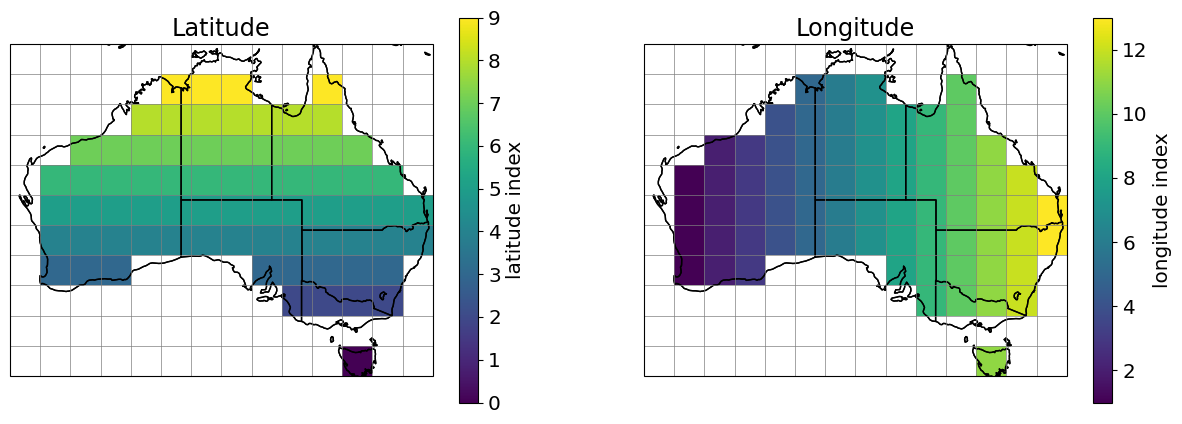

In [4]:
lon_array = xr.DataArray(
#    data=np.tile(mask.lon, (11, 1)),
    data=np.tile(np.arange(0,14), (11, 1)),
    coords={'lat': mask.lat, 'lon': mask.lon},
)

lat_array = xr.DataArray(
#    data=np.squeeze(np.dstack([mask.lat]*14)),
    data=np.squeeze(np.dstack([np.arange(0,11)]*14)),
    coords={'lat': mask.lat, 'lon': mask.lon},
) 

min_lat = mask.lat.values.min() - 1.5
max_lat = mask.lat.values.max() + 1.5
min_lon = mask.lon.values.min() - 1.5
max_lon = mask.lon.values.max() + 1.5

fig = plt.figure(figsize=[15, 5])

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
im1 = lat_array.where(mask).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'latitude index'},
)
ax1.set_title('Latitude')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
im2 = lon_array.where(mask).plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'longitude index'},
)
ax2.set_title('Longitude')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

for lon in mask.lon.values:
    ax1.plot([lon - 1.5, lon - 1.5], [min_lat, max_lat], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
    ax2.plot([lon - 1.5, lon - 1.5], [min_lat, max_lat], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
for lat in mask.lat.values:
    ax1.plot([min_lon, max_lon], [lat - 1.5, lat - 1.5], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
    ax2.plot([min_lon, max_lon], [lat - 1.5, lat - 1.5], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)

plt.show()

In [5]:
mask.lat[5]

<xarray.DataArray 'lat' ()> Size: 8B
array(-27.)
Coordinates:
    lat      float64 8B -27.0
    region   int64 8B 0
    abbrevs  <U3 12B 'AUS'
    names    <U9 36B 'Australia'
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

## Plot rx1day data

In [6]:
return_period = 1000
infile = 'rx1day_spatial.nc'
ds = xr.open_dataset(infile)

In [7]:
ds

<xarray.Dataset> Size: 19kB
Dimensions:  (lev: 2, lat: 11, lon: 14)
Coordinates:
  * lev      (lev) int64 16B 100 1000
  * lat      (lat) float64 88B -42.0 -39.0 -36.0 -33.0 ... -18.0 -15.0 -12.0
  * lon      (lon) float64 112B 113.5 116.5 119.5 122.5 ... 146.5 149.5 152.5
Data variables:
    G        (lev, lat, lon) float64 2kB ...
    M        (lev, lat, lon) float64 2kB ...
    B        (lev, lat, lon) float64 2kB ...
    T        (lev, lat, lon) float64 2kB ...
    O        (lev, lat, lon) float64 2kB ...
    MMM      (lev, lat, lon) float64 2kB ...
    obs      (lev, lat, lon) float64 2kB ...
    nmodels  (lat, lon) float64 1kB ...
Attributes:
    metric:   rx1day

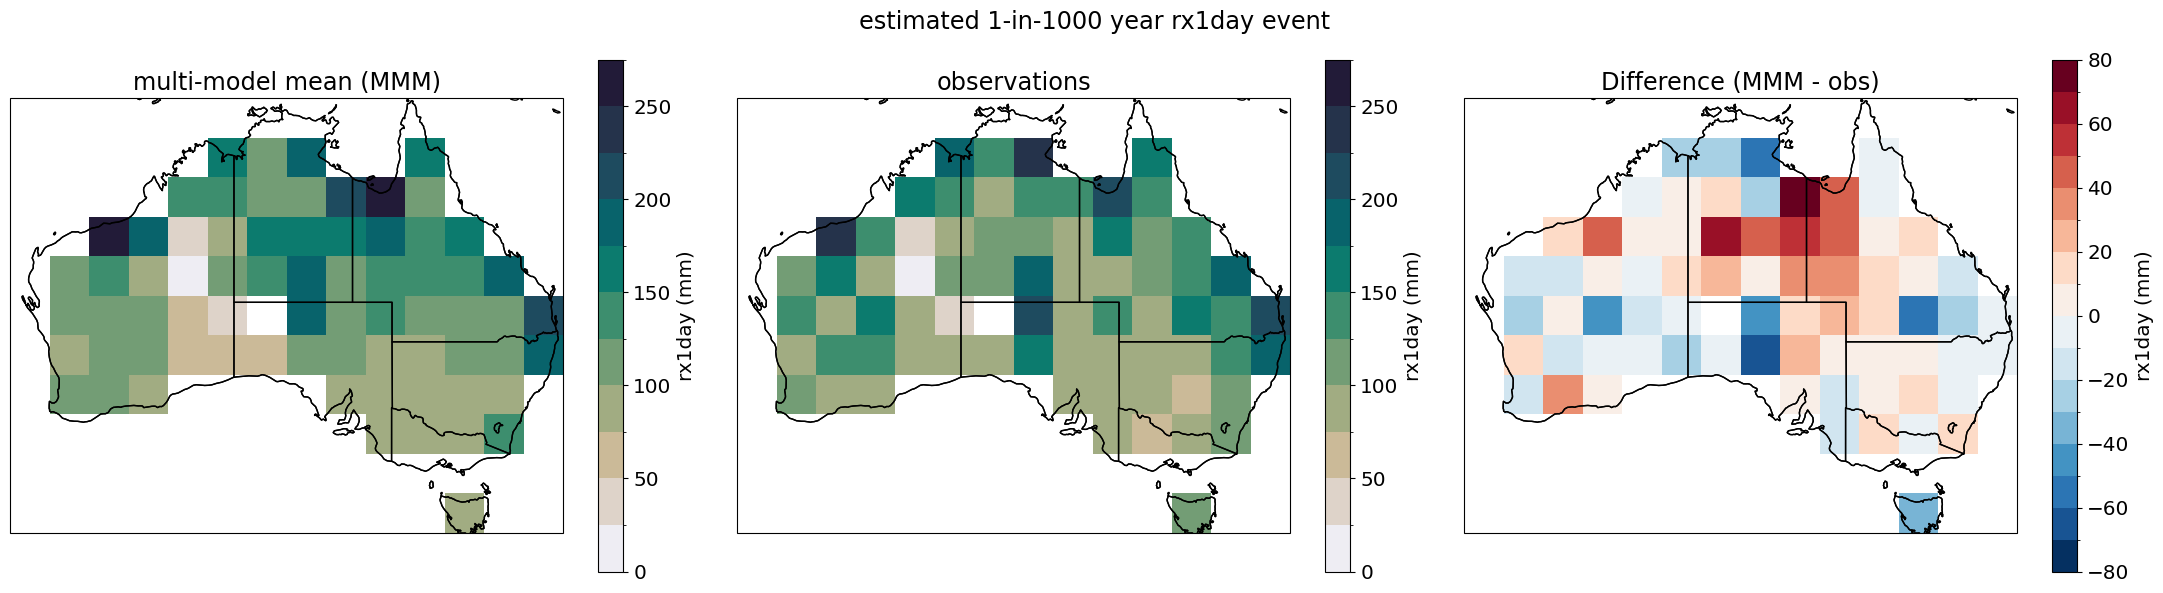

In [8]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds.sel({'lev': return_period})['MMM'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rx1day (mm)'},
    levels=np.arange(0, 276, 25),
    cmap=cmocean.cm.rain,
)
ax1.set_title('multi-model mean (MMM)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds.sel({'lev': return_period})['obs'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rx1day (mm)'},
    levels=np.arange(0, 276, 25),
    cmap=cmocean.cm.rain,
)
ax2.set_title('observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

diff = ds.sel({'lev': return_period})['MMM'] - ds.sel({'lev': return_period})['obs']
ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = diff.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rx1day (mm)'},
    levels=[-80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80],
    cmap='RdBu_r',
)
ax3.set_title('Difference (MMM - obs)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

plt.suptitle(f'estimated 1-in-{return_period} year rx1day event', fontsize='xx-large')
plt.tight_layout()
plt.show()

In [9]:
ratio = ds.sel({'lev': return_period})['T'] / ds.sel({'lev': return_period})['O']

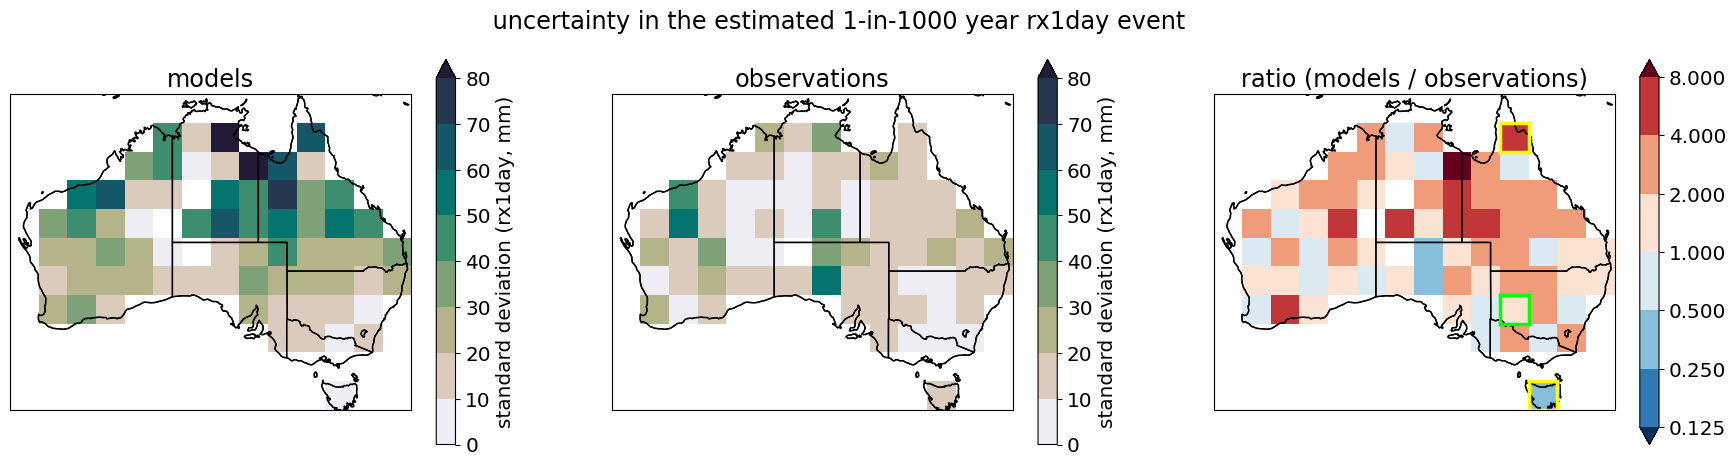

In [10]:
fig = plt.figure(figsize=[22, 5])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds.sel({'lev': return_period})['T'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'standard deviation (rx1day, mm)'},
    levels=np.arange(0, 90, 10),
    extend='max',
    cmap=cmocean.cm.rain,
)
ax1.set_title('models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds.sel({'lev': return_period})['O'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'standard deviation (rx1day, mm)'},
    levels=np.arange(0, 90, 10),
    extend='max',
    cmap=cmocean.cm.rain,
)
ax2.set_title('observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ratio.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('ratio (models / observations)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

highlight_grid_box(ax3, 0, 11, color='yellow')
highlight_grid_box(ax3, 9, 10, color='yellow')
highlight_grid_box(ax3, 3, 10, color='lime')

plt.suptitle(f' uncertainty in the estimated 1-in-{return_period} year rx1day event', fontsize='xx-large')
plt.show()

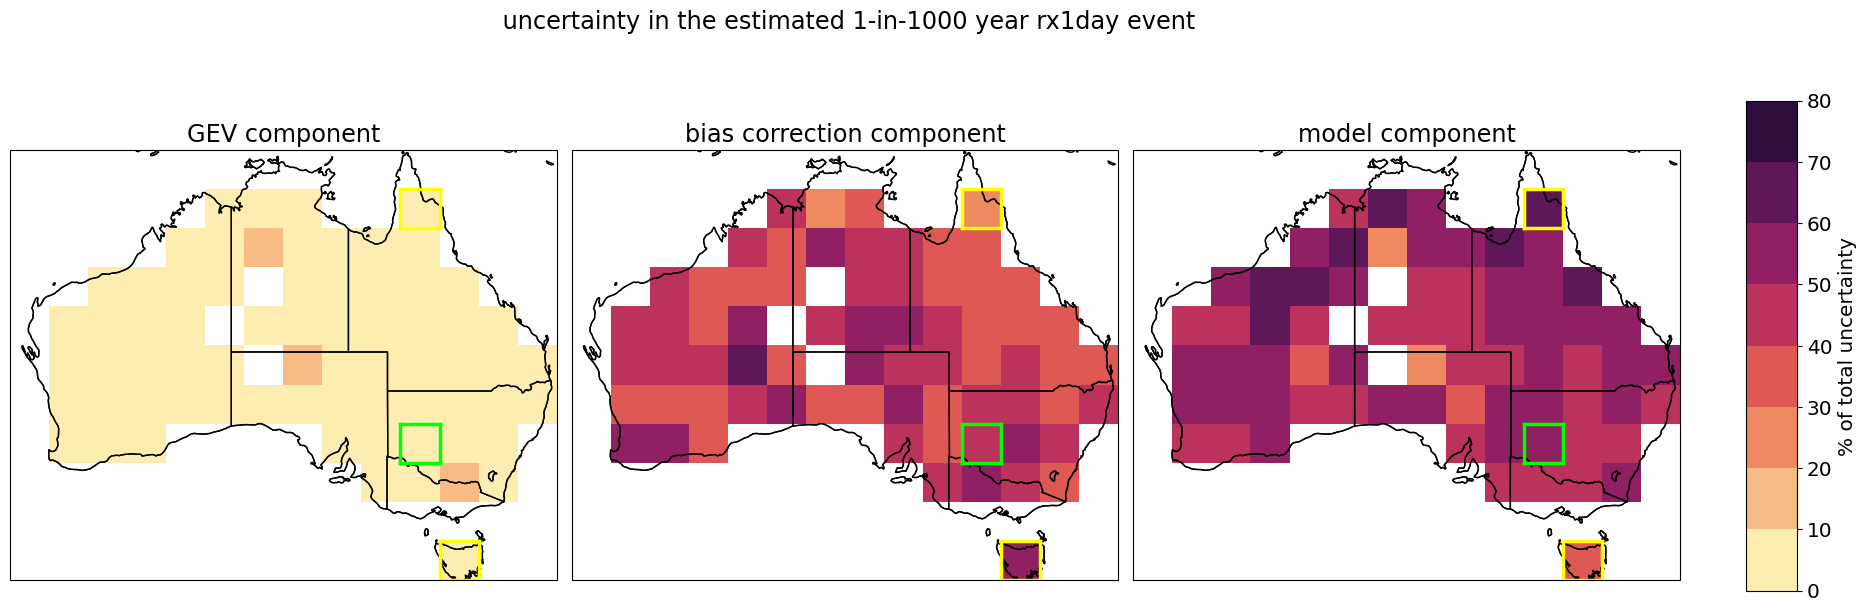

In [11]:
fig = plt.figure(figsize=[17, 7])
cbar_levels = np.arange(0, 81, 10)
cmap = cmocean.cm.matter

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds.sel({'lev': return_period})['G'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax1.set_title('GEV component')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds.sel({'lev': return_period})['B'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax2.set_title('bias correction component')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ds.sel({'lev': return_period})['M'].plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax3.set_title('model component')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

highlight_grid_box(ax1, 0, 11, color='yellow')
highlight_grid_box(ax2, 0, 11, color='yellow')
highlight_grid_box(ax3, 0, 11, color='yellow')
highlight_grid_box(ax1, 9, 10, color='yellow')
highlight_grid_box(ax2, 9, 10, color='yellow')
highlight_grid_box(ax3, 9, 10, color='yellow')

highlight_grid_box(ax1, 3, 10, color='lime')
highlight_grid_box(ax2, 3, 10, color='lime')
highlight_grid_box(ax3, 3, 10, color='lime')

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='% of total uncertainty')

plt.suptitle(f' uncertainty in the estimated 1-in-{return_period} year rx1day event', fontsize='xx-large')
plt.tight_layout()
plt.show()

In [10]:
g_max = float(ds.sel({'lev': return_period})['G'].max())
g_mean = float(ds.sel({'lev': return_period})['G'].mean())
g_min = float(ds.sel({'lev': return_period})['G'].min())

print(f'GEV uncertainty maximum: {g_max:.1f}%')
print(f'GEV uncertainty mean: {g_mean:.1f}%')
print(f'GEV uncertainty minimum: {g_min:.1f}%')

GEV uncertainty maximum: 17.0%
GEV uncertainty mean: 5.8%
GEV uncertainty minimum: 2.1%


In [11]:
b_max = float(ds.sel({'lev': return_period})['B'].max())
b_mean = float(ds.sel({'lev': return_period})['B'].mean())
b_min = float(ds.sel({'lev': return_period})['B'].min())

print(f'bias correction uncertainty maximum: {b_max:.1f}%')
print(f'bias correction uncertainty mean: {b_mean:.1f}%')
print(f'bias correction uncertainty minimum: {b_min:.1f}%')

bias correction uncertainty maximum: 62.4%
bias correction uncertainty mean: 42.9%
bias correction uncertainty minimum: 29.2%


In [12]:
m_max = float(ds.sel({'lev': return_period})['M'].max())
m_mean = float(ds.sel({'lev': return_period})['M'].mean())
m_min = float(ds.sel({'lev': return_period})['M'].min())

print(f'model uncertainty maximum: {m_max:.1f}%')
print(f'model uncertainty mean: {m_mean:.1f}%')
print(f'model uncertainty minimum: {m_min:.1f}%')

model uncertainty maximum: 66.9%
model uncertainty mean: 51.3%
model uncertainty minimum: 27.6%


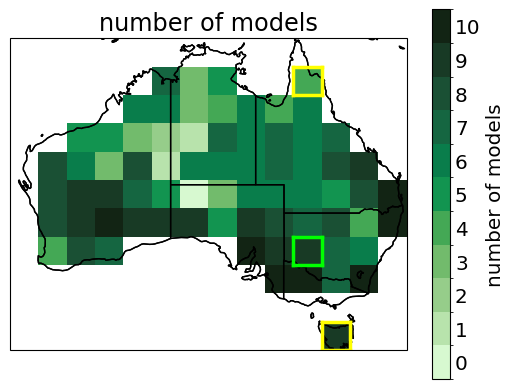

In [12]:
fig = plt.figure()#figsize=[5, 5])

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = ds['nmodels'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax1.set_title('number of models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

cbar = fig.colorbar(im1, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar.ax.tick_params(size=0)

highlight_grid_box(ax1, 0, 11, color='yellow')
highlight_grid_box(ax1, 9, 10, color='yellow')
highlight_grid_box(ax1, 3, 10, color='lime')

plt.show()

## Plot txx data

In [13]:
return_period = 1000
infile = 'txx_spatial.nc'
ds = xr.open_dataset(infile)

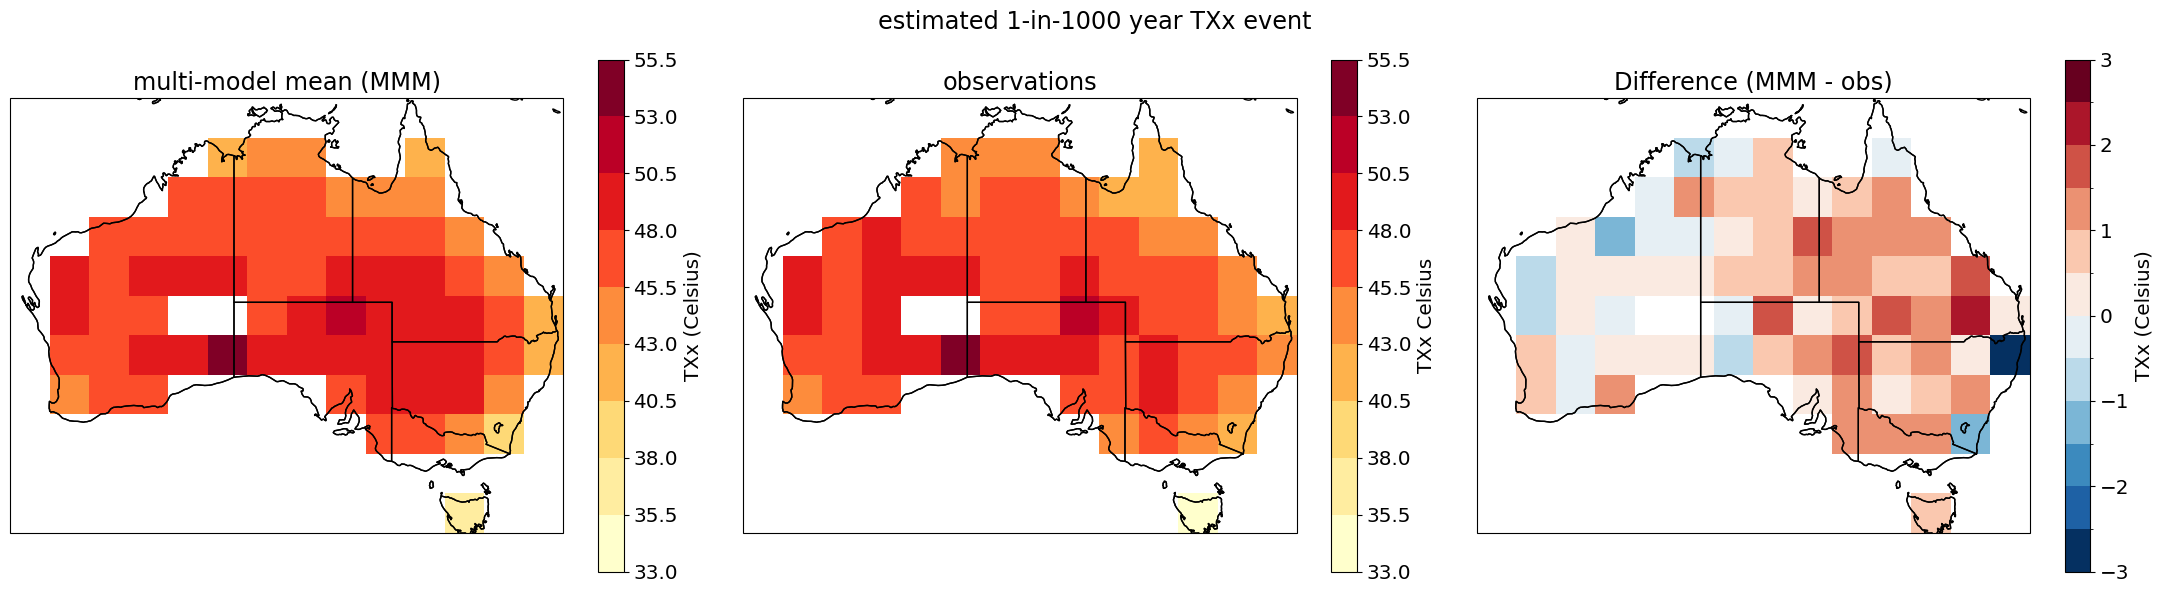

In [14]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds.sel({'lev': return_period})['MMM'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'TXx (Celsius)'},
    levels=np.arange(33, 56, 2.5),
    cmap='YlOrRd',
)
ax1.set_title('multi-model mean (MMM)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds.sel({'lev': return_period})['obs'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'TXx Celsius'},
    levels=np.arange(33, 56, 2.5),
    cmap='YlOrRd',
)
ax2.set_title('observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

diff = ds.sel({'lev': return_period})['MMM'] - ds.sel({'lev': return_period})['obs']
ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = diff.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'TXx (Celsius)'},
    levels=[-3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
    cmap='RdBu_r',
)
ax3.set_title('Difference (MMM - obs)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

plt.suptitle(f'estimated 1-in-{return_period} year TXx event', fontsize='xx-large')
plt.tight_layout()
plt.show()

In [15]:
ratio = ds.sel({'lev': return_period})['T'] / ds.sel({'lev': return_period})['O']

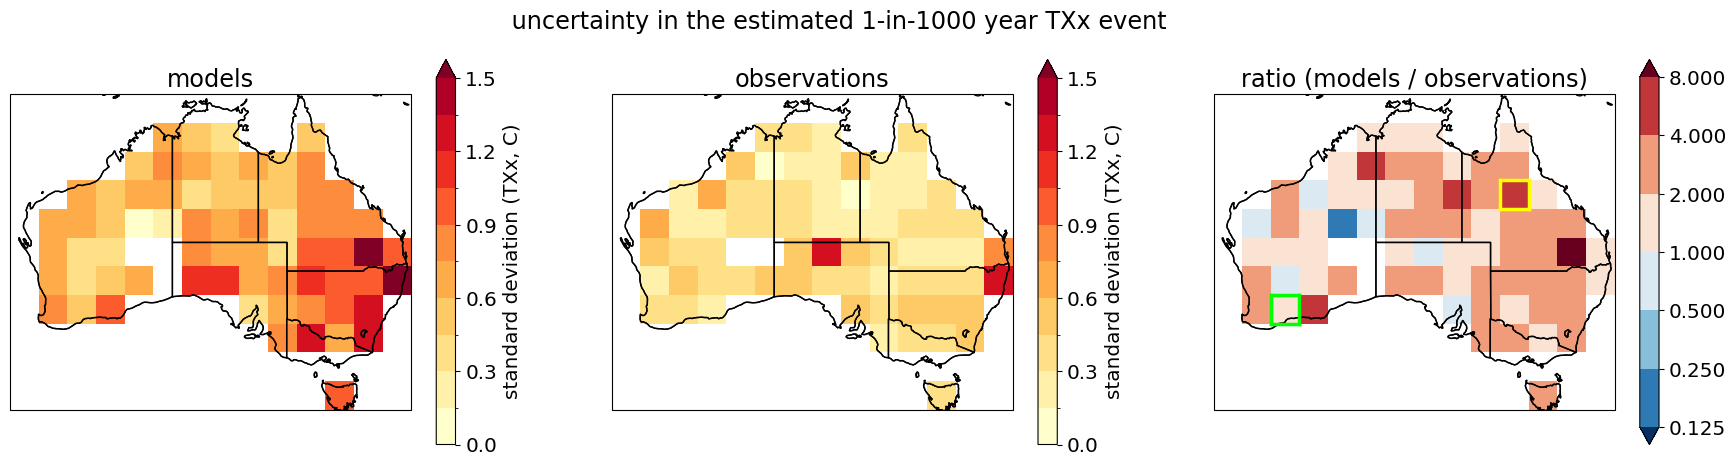

In [16]:
fig = plt.figure(figsize=[22, 5])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds.sel({'lev': return_period})['T'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'standard deviation (TXx, C)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax1.set_title('models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds.sel({'lev': return_period})['O'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'standard deviation (TXx, C)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax2.set_title('observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ratio.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('ratio (models / observations)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

highlight_grid_box(ax3, 7, 10, color='yellow')
highlight_grid_box(ax3, 3, 2, color='lime')

plt.suptitle(f' uncertainty in the estimated 1-in-{return_period} year TXx event', fontsize='xx-large')
plt.show()

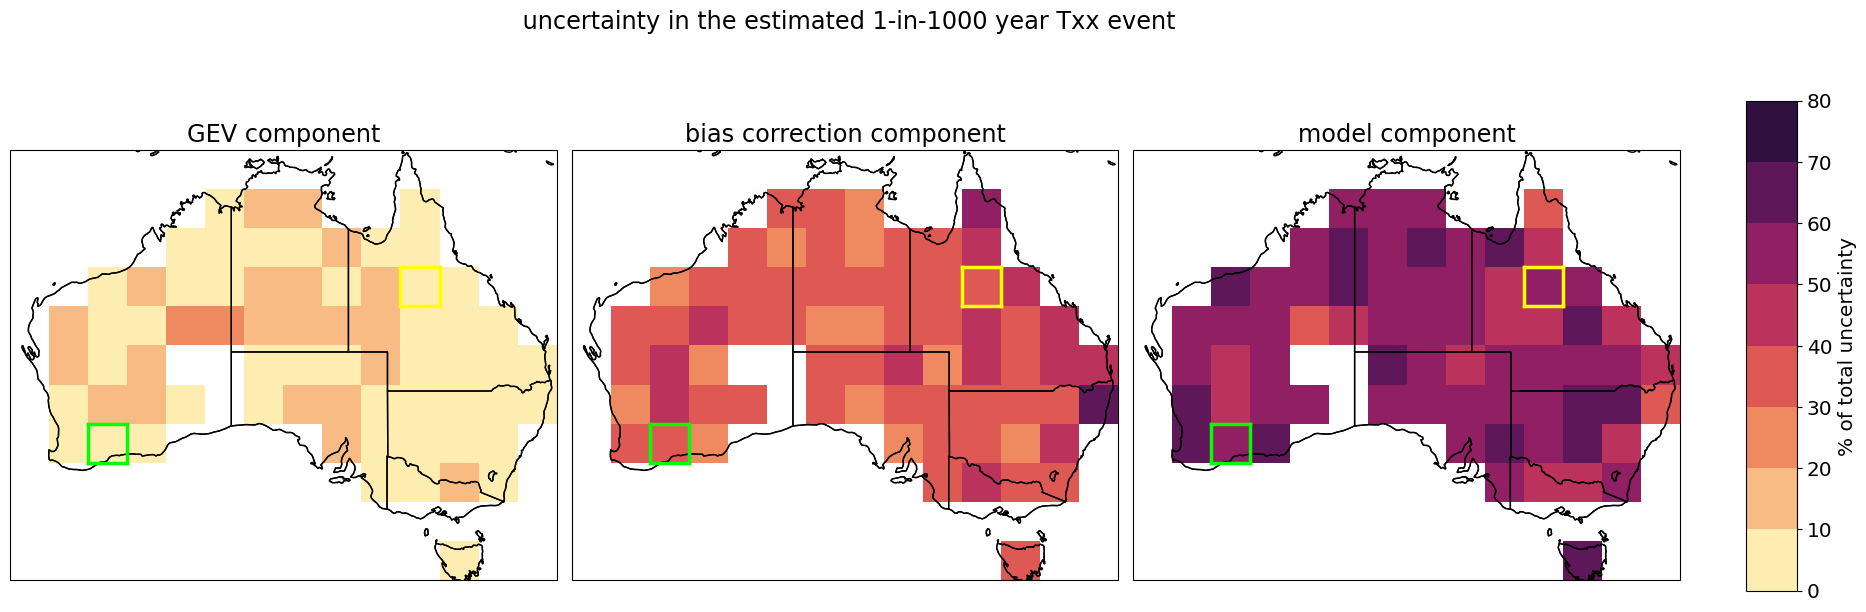

In [17]:
fig = plt.figure(figsize=[17, 7])
cbar_levels = np.arange(0, 81, 10)
cmap = cmocean.cm.matter

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds.sel({'lev': return_period})['G'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax1.set_title('GEV component')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds.sel({'lev': return_period})['B'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax2.set_title('bias correction component')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ds.sel({'lev': return_period})['M'].plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax3.set_title('model component')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='% of total uncertainty')

highlight_grid_box(ax1, 3, 2, color='lime')
highlight_grid_box(ax2, 3, 2, color='lime')
highlight_grid_box(ax3, 3, 2, color='lime')

highlight_grid_box(ax1, 7, 10, color='yellow')
highlight_grid_box(ax2, 7, 10, color='yellow')
highlight_grid_box(ax3, 7, 10, color='yellow')

plt.suptitle(f' uncertainty in the estimated 1-in-{return_period} year Txx event', fontsize='xx-large')
plt.tight_layout()
plt.show()

In [18]:
g_max = float(ds.sel({'lev': return_period})['G'].max())
g_mean = float(ds.sel({'lev': return_period})['G'].mean())
g_min = float(ds.sel({'lev': return_period})['G'].min())

print(f'GEV uncertainty maximum: {g_max:.1f}%')
print(f'GEV uncertainty mean: {g_mean:.1f}%')
print(f'GEV uncertainty minimum: {g_min:.1f}%')

GEV uncertainty maximum: 29.2%
GEV uncertainty mean: 9.7%
GEV uncertainty minimum: 3.8%


In [19]:
b_max = float(ds.sel({'lev': return_period})['B'].max())
b_mean = float(ds.sel({'lev': return_period})['B'].mean())
b_min = float(ds.sel({'lev': return_period})['B'].min())

print(f'bias correction uncertainty maximum: {b_max:.1f}%')
print(f'bias correction uncertainty mean: {b_mean:.1f}%')
print(f'bias correction uncertainty minimum: {b_min:.1f}%')

bias correction uncertainty maximum: 60.2%
bias correction uncertainty mean: 35.7%
bias correction uncertainty minimum: 23.8%


In [20]:
m_max = float(ds.sel({'lev': return_period})['M'].max())
m_mean = float(ds.sel({'lev': return_period})['M'].mean())
m_min = float(ds.sel({'lev': return_period})['M'].min())

print(f'model uncertainty maximum: {m_max:.1f}%')
print(f'model uncertainty mean: {m_mean:.1f}%')
print(f'model uncertainty minimum: {m_min:.1f}%')

model uncertainty maximum: 67.1%
model uncertainty mean: 54.6%
model uncertainty minimum: 36.1%


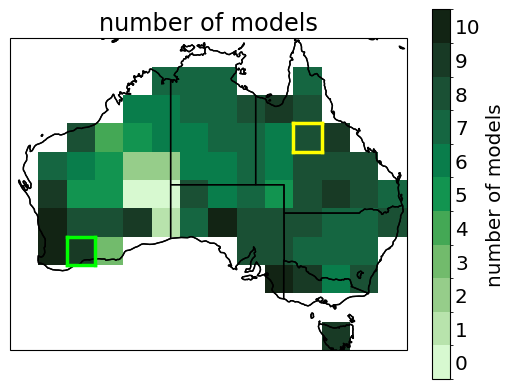

In [21]:
fig = plt.figure()#figsize=[5, 5])

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = ds['nmodels'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax1.set_title('number of models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

cbar = fig.colorbar(im1, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar.ax.tick_params(size=0)

highlight_grid_box(ax1, 7, 10, color='yellow')
highlight_grid_box(ax1, 3, 2, color='lime')

plt.show()